# Protocolo experimental operando: simulación, RMN multinuclear y quimiometría

**Vía experimental de BatteryAsTank / atom-to-reactor.** Este notebook analiza el protocolo de banco de TMSPA en EC húmedo y se apoya en el motor modular `kinetics/` para reproducir las observaciones del laboratorio de Ångström e inyectar la complejidad de nuestros modelos cinéticos.

El documento se estructura en **6 secciones continuas**:
1. **Receta Volumétrica y Dilución en Disolución:** Conversión de vol% a molaridades con dilución física al inyectar TMSPA.
2. **Protocolo Experimental Térmico:** Cronograma de 16 etapas (pre-equilibración + rampa 20 °C → 80 °C + adquisiciones a 20 °C).
3. **Simulación Radau IIA y Comparativa de Modelos:** Integración rígida y contraste in-situ entre el **Baseline Peter ($E_0=1.15\text{ eV}$)** y el **Modelo Calibrado por Familias (Gogoi 2024: $0.80/1.30\text{ eV}$)**.
4. **RMN Multinuclear Operando:** Generación de espectros sintéticos apilados para $^{29}\text{Si}$, $^{31}\text{P}$, $^{13}\text{C}$ y $^{1}\text{H}$.
5. **Dinámica de Protones Lábiles y Balance Analítico de Agua:** Coalescencia rápida de -OH y deducción exacta de $[\text{H}_2\text{O}]$ por balance de masa.
6. **Quimiometría: Huellas de Reacción, Identifiabilidad SVD e Inversión:** Descomposición SVD (rango 6/9), selectividad NAS e inversión de avances $\Delta\boldsymbol{\xi}$ con ruido sintético.


In [1]:
import os
import sys
from copy import deepcopy

sys.path.insert(0, '..')
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kinetics import (
    compute_recipe_molarities,
    build_default_protocol_schedule,
    simulate_protocol_reactor,
    build_referenced_nmr_sites,
    simulate_multinuclear_spectra,
    site_peaks,
    auto_regions,
    compute_water_mass_balance,
    lorentzian,
    DEFAULT_NUCLEI,
    DEFAULT_SPECIES,
    load_default_species_database,
    build_multinuclear_feature_space,
    build_pure_component_matrix,
    build_reaction_fingerprints,
    analyze_reaction_identifiability,
    recover_reaction_extents,
)
from kinetics.microkinetics.rate_constants import DEFAULT_FAMILY_BEP_PARAMETERS
from kinetics.spectroscopy.molecular_symmetry import load_dataset_snapshot
from kinetics.thermo.species_data import HAR2EV

plt.rcParams.update({
    'font.sans-serif': 'DejaVu Sans',
    'font.family': 'sans-serif',
    'figure.dpi': 150,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'grid.alpha': 0.4,
    'grid.linestyle': '--'
})

print('Atom-to-reactor modules imported. No simulation has been run yet.')


Atom-to-reactor modules imported. No simulation has been run yet.


## 1. Receta Volumétrica y Dilución en Disolución

Traduce los volúmenes de banco del operador ($2\text{ vol}\%\text{ H}_2\text{O}$ stock en EC, adición posterior de $5\text{ vol}\%\text{ TMSPA}$) a molaridades exactas utilizando densidades y masas molares. Modela el factor de dilución física $(1 - \phi_{\text{TMSPA}} = 0.95)$ al inyectar el reactivo.


In [2]:
recipe = compute_recipe_molarities(
    h2o_vol_frac_stock=0.02,
    tmspa_vol_frac=0.05
)

print(f"H2O : TMSPA initial molar ratio = {recipe['h2o_tmspa_ratio']:.2f} : 1 (Water in large excess)")
recipe['summary_df'].round(4)


H2O : TMSPA initial molar ratio = 7.04 : 1 (Water in large excess)


,vol% (final),stock (M),after injection (M)
EC,93.1,14.7008,13.9657
H2O,1.9,1.1069,1.0515
TMSPA,5.0,0.0000,0.1494


## 2. Cronograma del Protocolo Experimental Térmico

Define la secuencia cronológica de 16 etapas:
1. Agitación de pre-equilibración a $20^\circ\text{C}$ ($24\text{ h}$).
2. Reposo a $20^\circ\text{C}$ ($12\text{ h}$).
3. **Inyección discreta de TMSPA** (anclada en $t = 0$).
4. Escalones isotermos de temperatura ($20, 30, 40, 50, 60, 70, 80^\circ\text{C}$, $8\text{ h}$ cada uno).
5. Adquisición de RMN a temperatura ambiente ($20^\circ\text{C}$, $1\text{ h}$) tras cada escalón térmico.


In [3]:
stages, sched_df = build_default_protocol_schedule()
sched_df


,stage,T (°C),duration (h),start (h),end (h),acquisition
0,"EC + H2O, stirred",20.0,24.0,-36.0,-12.0,
1,equilibrate,20.0,12.0,-12.0,0.0,
2,hold 20 C,20.0,8.0,0.0,8.0,
3,acquire (20 C),20.0,1.0,8.0,9.0,20 °C
4,hold 30 C,30.0,8.0,9.0,17.0,
5,acquire (30 C),20.0,1.0,17.0,18.0,30 °C
6,hold 40 C,40.0,8.0,18.0,26.0,
7,acquire (40 C),20.0,1.0,26.0,27.0,40 °C
8,hold 50 C,50.0,8.0,27.0,35.0,
9,acquire (50 C),20.0,1.0,35.0,36.0,50 °C


## 3. Simulación Radau IIA y Comparativa de Modelos: Peter vs. Gogoi 2024

Integra el sistema de EDOs rígidas etapa por etapa utilizando el algoritmo implícito de Radau IIA (orden 5). Permite contrastar dos filosofías cinéticas sobre el mismo protocolo experimental:
- **`peter_reference` (Baseline Peter):** Modelo forward fenomenológico con un único $E_0 = 1.15\text{ eV}$ idéntico para todas las reacciones y Gibbs tabulado.
- **`family_barrier_sensitivity` (Gogoi et al. 2024):** Modelo mecanicista calibrado por familias ($E_0 = 0.80\text{ eV}$ para hidrólisis/condensación/transferencia; $E_0 = 1.30\text{ eV}$ para apertura de anillo de EC).

Por defecto se activa el modo comparativo (`compare_available`), que ejecuta ambos modelos sobre el mismo cronograma para analizar las discrepancias en el consumo de TMSPA y formación de $\text{CO}_2$.


In [4]:
# Único selector que cambia el modelo aplicado al reactor y a todos los análisis posteriores.
MODEL_VARIANT = 'compare_available'
# Opciones: 'peter_reference', 'family_barrier_sensitivity',
#           'family_marcus_sensitivity', 'compare_available', 'full_multiscale_qrrho'

POINTS_PER_STAGE = 120
INJECTION_STAGE_IDX = 2

SPECIES_DB = deepcopy(load_default_species_database())
SNAPSHOT = load_dataset_snapshot()
source_by_id = {item['pipeline_id']: item for item in SNAPSHOT.get('datasets', [])}
for species_name, record in SPECIES_DB.items():
    source_record = source_by_id.get(species_name)
    if source_record and source_record.get('energy_scf_eh') is not None:
        # Feed the raw SCF energy to the qRRHO route; the stored Gibbs value is not E_0K.
        record['E_0K_eV'] = float(source_record['energy_scf_eh']) * HAR2EV
        record['energy_reference'] = 'energy_scf_eh'

PETER_BEP = {'default': {'E0_eV': 1.15, 'alpha': 0.50}}
FAMILY_BEP = deepcopy(DEFAULT_FAMILY_BEP_PARAMETERS)
MODEL_CONFIGS = {
    'peter_reference': {
        'label': 'Peter reference: tabulated Gibbs + global BEP',
        'thermo_mode': 'wb97mv',
        'kinetic_model': 'bep_eyring',
        'bep_params': PETER_BEP,
    },
    'family_barrier_sensitivity': {
        'label': 'Family barrier sensitivity: tabulated Gibbs + family BEP',
        'thermo_mode': 'wb97mv',
        'kinetic_model': 'bep_eyring',
        'bep_params': FAMILY_BEP,
    },
    'family_marcus_sensitivity': {
        'label': 'Marcus sensitivity: tabulated Gibbs + family parameters',
        'thermo_mode': 'wb97mv',
        'kinetic_model': 'marcus_eyring',
        'bep_params': FAMILY_BEP,
    },
    'full_multiscale_qrrho': {
        'label': 'Full multiscale: qRRHO(T) + family BEP',
        'thermo_mode': 'qRRHO',
        'kinetic_model': 'bep_eyring',
        'bep_params': FAMILY_BEP,
    },
}
if MODEL_VARIANT not in set(MODEL_CONFIGS) | {'compare_available'}:
    choices = sorted(set(MODEL_CONFIGS) | {'compare_available'})
    raise ValueError(f'Unknown MODEL_VARIANT={MODEL_VARIANT!r}. Choose from {choices}')

# Compare mode runs Peter's baseline and the family-BEP sensitivity with identical stored-Gibbs inputs.
model_config = MODEL_CONFIGS['peter_reference'] if MODEL_VARIANT == 'compare_available' else MODEL_CONFIGS[MODEL_VARIANT]
if MODEL_VARIANT == 'full_multiscale_qrrho':
    required_qrrho_fields = ('frequencies_cm1', 'moments_amu_A2')
    missing_qrrho = {
        sp: [field for field in required_qrrho_fields if not SPECIES_DB.get(sp, {}).get(field)]
        for sp in DEFAULT_SPECIES
    }
    missing_qrrho = {sp: fields for sp, fields in missing_qrrho.items() if fields}
    missing_energy = [sp for sp in DEFAULT_SPECIES
                      if SPECIES_DB.get(sp, {}).get('energy_reference') != 'energy_scf_eh']
    if missing_qrrho or missing_energy:
        detail = '; '.join(f'{sp}: {", ".join(fields)}' for sp, fields in missing_qrrho.items())
        if missing_energy:
            detail += ('; ' if detail else '') + 'raw SCF energy missing: ' + ', '.join(missing_energy)
        raise RuntimeError(
            'Full qRRHO(T) is not available from the current snapshot. '
            'Add species-specific frequencies, moments of inertia, and raw SCF energies. ' + detail
        )

if MODEL_VARIANT == 'compare_available':
    print('Comparison mode: Peter reference vs family-barrier sensitivity; both use stored Gibbs data.')
else:
    print(f"Selected model: {model_config['label']}")
print(f"Thermochemistry mode: {model_config['thermo_mode']} | Kinetic model: {model_config['kinetic_model']}")


Comparison mode: Peter reference vs family-barrier sensitivity; both use stored Gibbs data.
Thermochemistry mode: wb97mv | Kinetic model: bep_eyring


### 3.1. Integración Numérica por Etapas Encadenadas

Resuelve las ecuaciones cinéticas $d\mathbf{C}/dt = \mathbf{S} \cdot \mathbf{r}$ encadenando el estado final de cada etapa como condición inicial de la siguiente, recalculando las constantes de velocidad $k_f(T)$ y $k_r(T)$ con la temperatura de cada escalón y comprobando la conservación estricta de silicio y fósforo post-inyección.


In [5]:
# In compare mode, run both available parameterizations against the same protocol and stored Gibbs data.
variants_to_run = (
    ['peter_reference', 'family_barrier_sensitivity']
    if MODEL_VARIANT == 'compare_available'
    else [MODEL_VARIANT]
)
simulations = {}
for variant_name in variants_to_run:
    cfg = MODEL_CONFIGS[variant_name]
    simulations[variant_name] = simulate_protocol_reactor(
        stages=stages,
        recipe=recipe,
        injection_stage_idx=INJECTION_STAGE_IDX,
        points_per_stage=POINTS_PER_STAGE,
        thermo_mode=cfg['thermo_mode'],
        bep_params=cfg['bep_params'],
        kinetic_model=cfg['kinetic_model'],
        species_db=SPECIES_DB,
    )

# The remaining detailed diagnostics use Peter's reference in comparison mode.
sim = simulations['peter_reference'] if MODEL_VARIANT == 'compare_available' else simulations[MODEL_VARIANT]
print(f"Simulation completed: {sim['t_h'][-1]:.1f} hours.")
print(f"TMSPA remaining: {sim['snapshots'][-1]['C'][sim['idx']['TMSPA']]*1000:.3f} mM "
      f"({sim['snapshots'][-1]['C'][sim['idx']['TMSPA']]/recipe['after']['TMSPA']*100:.2f}%)")
print(f"Silicon element conserved: {sim['si_conserved']}")
print(f"Phosphorus element conserved: {sim['p_conserved']}")


Simulation completed: 63.0 hours.
TMSPA remaining: 0.037 mM (0.02%)
Silicon element conserved: True
Phosphorus element conserved: True


### 3.2. Perfiles Temporales de Concentración y Comparativa de Modelos

Representa las trayectorias de concentración para la cascada de fosfatos, silanoles, agua y productos de apertura de disolvente, seguido de la comparativa superpuesta entre el modelo de Peter y la parametrización de Gogoi 2024.


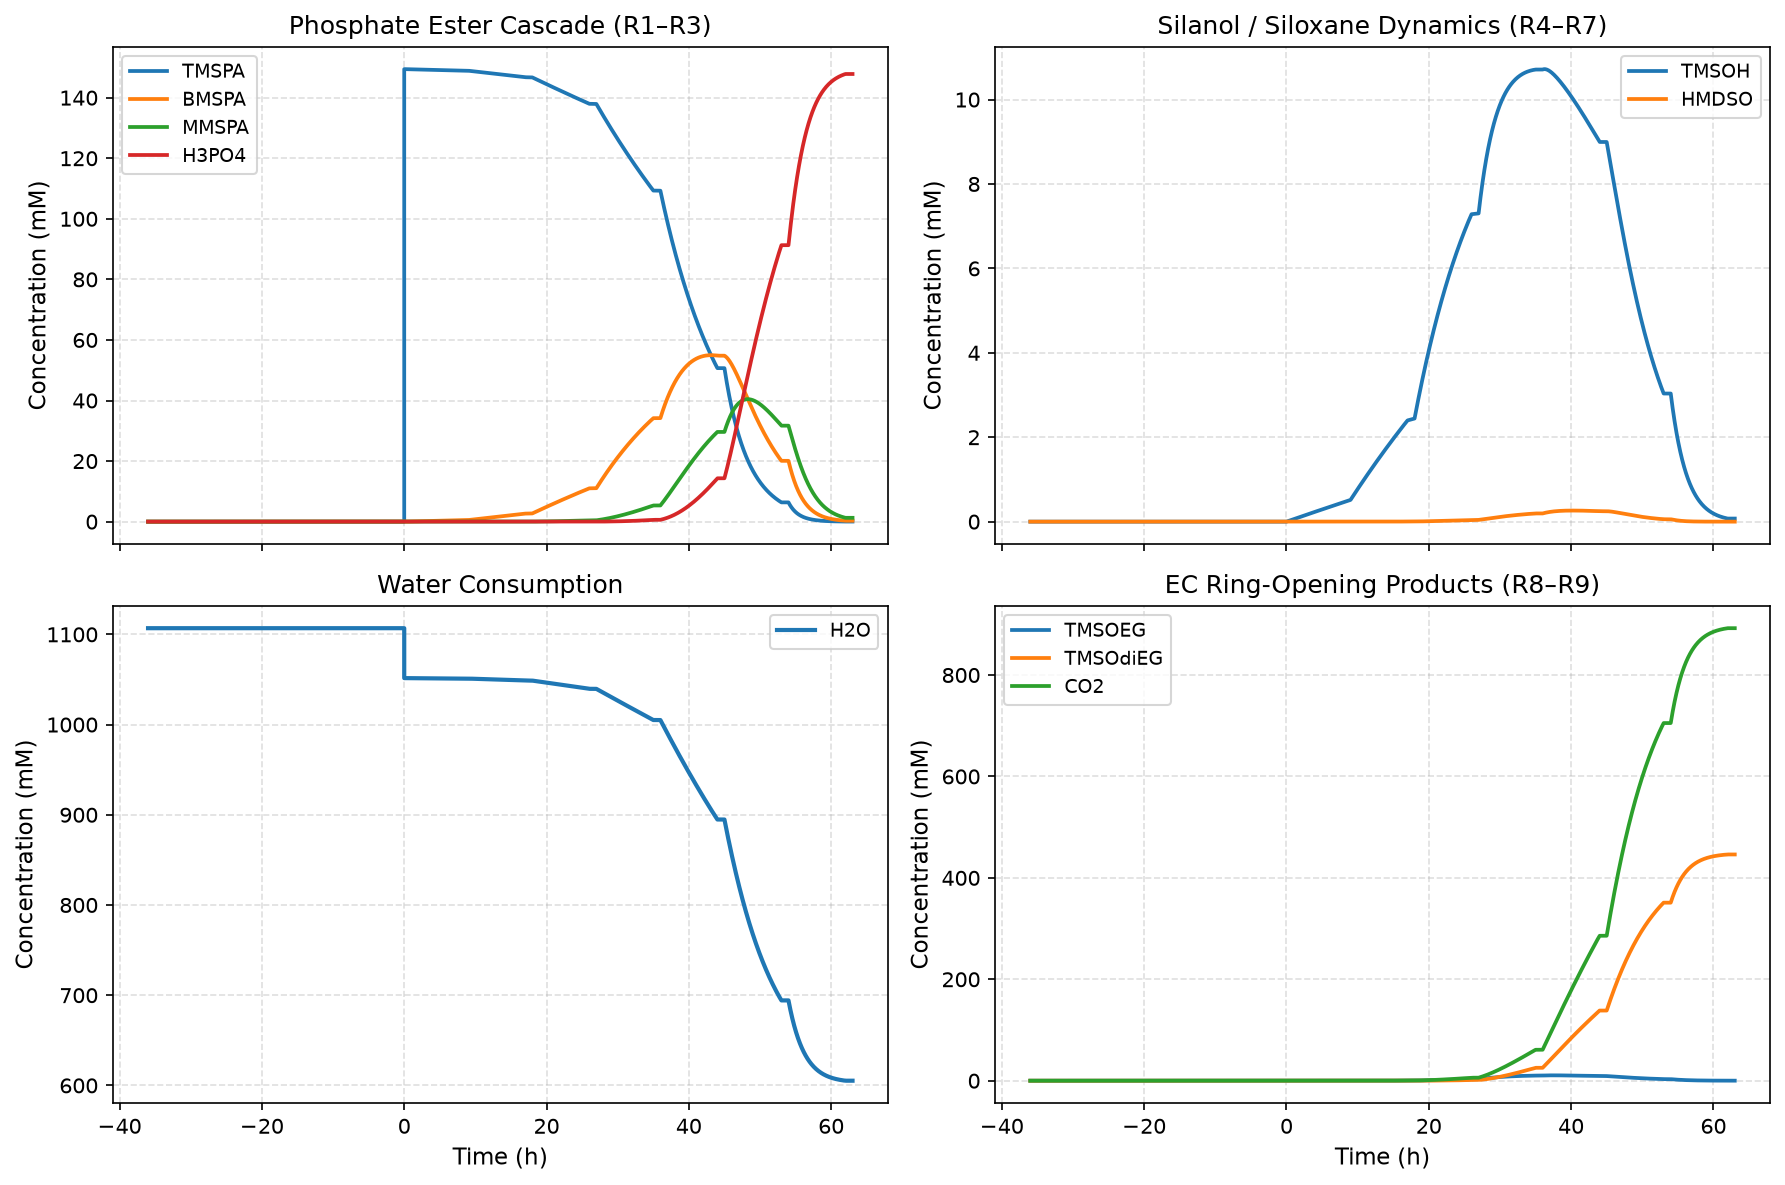

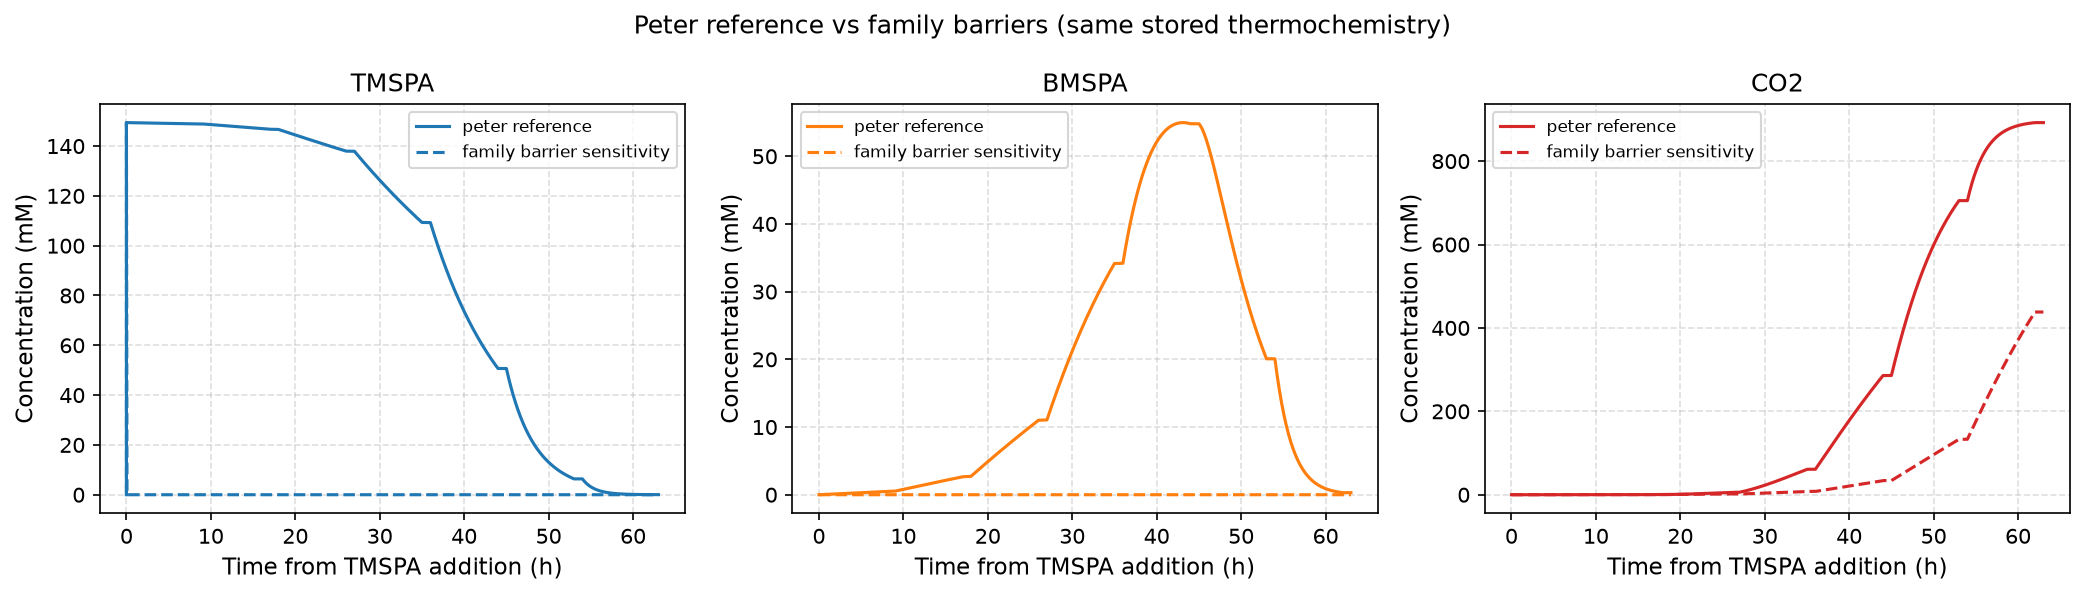

In [6]:
t_h = sim['t_h']
C_mM = sim['C_mM']
idx = sim['idx']

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

# Phosphate ladder
ax = axes[0, 0]
for sp in ['TMSPA', 'BMSPA', 'MMSPA', 'H3PO4']:
    ax.plot(t_h, C_mM[idx[sp]], lw=1.8, label=sp)
ax.set_ylabel('Concentration (mM)')
ax.set_title('Phosphate Ester Cascade (R1–R3)')
ax.legend(frameon=True)
ax.grid(True)

# Silanol / Siloxane
ax = axes[0, 1]
for sp in ['TMSOH', 'HMDSO']:
    ax.plot(t_h, C_mM[idx[sp]], lw=1.8, label=sp)
ax.set_ylabel('Concentration (mM)')
ax.set_title('Silanol / Siloxane Dynamics (R4–R7)')
ax.legend(frameon=True)
ax.grid(True)

# Water
ax = axes[1, 0]
ax.plot(t_h, C_mM[idx['H2O']], color='C0', lw=2.0, label='H2O')
ax.set_xlabel('Time (h)')
ax.set_ylabel('Concentration (mM)')
ax.set_title('Water Consumption')
ax.legend(frameon=True)
ax.grid(True)

# Solvent attack products
ax = axes[1, 1]
for sp in ['TMSOEG', 'TMSOdiEG', 'CO2']:
    ax.plot(t_h, C_mM[idx[sp]], lw=1.8, label=sp)
ax.set_xlabel('Time (h)')
ax.set_ylabel('Concentration (mM)')
ax.set_title('EC Ring-Opening Products (R8–R9)')
ax.legend(frameon=True)
ax.grid(True)

plt.tight_layout()
plt.show()


if MODEL_VARIANT == 'compare_available':
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
    compare_species = ['TMSPA', 'BMSPA', 'CO2']
    colors = {'TMSPA': 'C0', 'BMSPA': 'C1', 'CO2': 'C3'}
    styles = {'peter_reference': '-', 'family_barrier_sensitivity': '--'}
    for ax, sp in zip(axes, compare_species):
        for variant_name, case in simulations.items():
            mask = case['t_h'] >= 0
            ax.plot(case['t_h'][mask], case['C_mM'][case['idx'][sp], mask],
                    color=colors[sp], linestyle=styles[variant_name],
                    label=variant_name.replace('_', ' '))
        ax.set_title(sp)
        ax.set_xlabel('Time from TMSPA addition (h)')
        ax.set_ylabel('Concentration (mM)')
        ax.grid(True)
        ax.legend(frameon=True, fontsize=8)
    fig.suptitle('Peter reference vs family barriers (same stored thermochemistry)')
    plt.tight_layout()
    plt.show()

    comparison = []
    for variant_name, case in simulations.items():
        final = case['snapshots'][-1]['C']
        comparison.append({
            'Model': variant_name,
            'TMSPA remaining (mM)': final[case['idx']['TMSPA']] * 1000,
            'CO2 final (mM)': final[case['idx']['CO2']] * 1000,
            'Max CO2 (mM)': case['C_mM'][case['idx']['CO2']].max(),
        })
    pd.DataFrame(comparison).set_index('Model').round(3)


## 4. RMN Multinuclear Operando ($^{29}\text{Si}, ^{31}\text{P}, ^{13}\text{C}, ^{1}\text{H}$)

Genera los espectros sintéticos apilados para cada adquisición tras los escalones de temperatura. Utiliza los apantallamientos magnéticos isotrópicos DFT GIAO promediados sobre clases de equivalencia topológica por grafos (`kinetics.spectroscopy.molecular_symmetry`), agrupando las ventanas químicas con `auto_regions` para omitir regiones vacías.


/var/folders/p9/lpxbgdp50rqbqty02d2qwksh0000gn/T/ipykernel_98533/3481823782.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


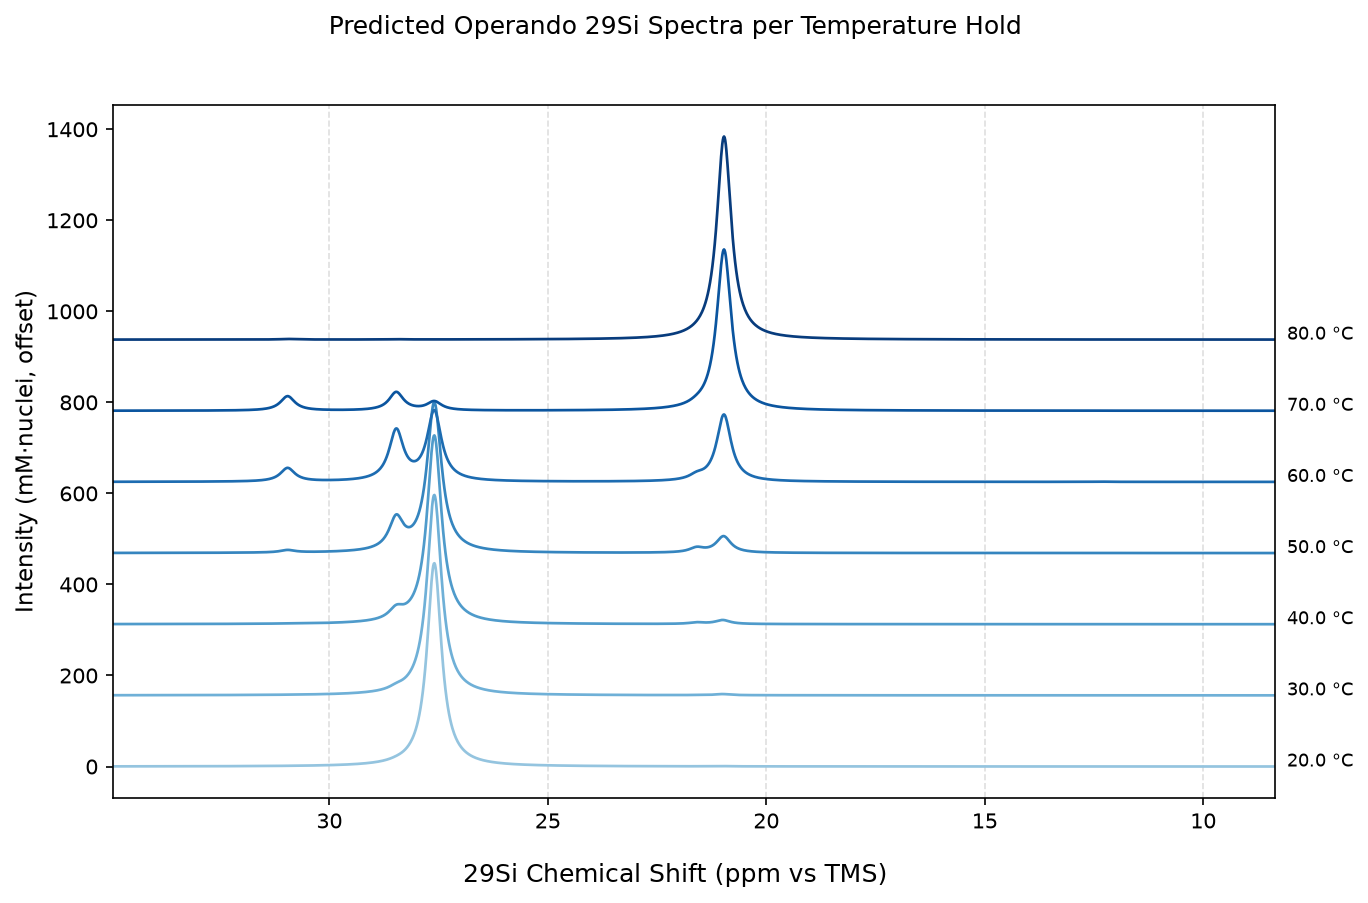

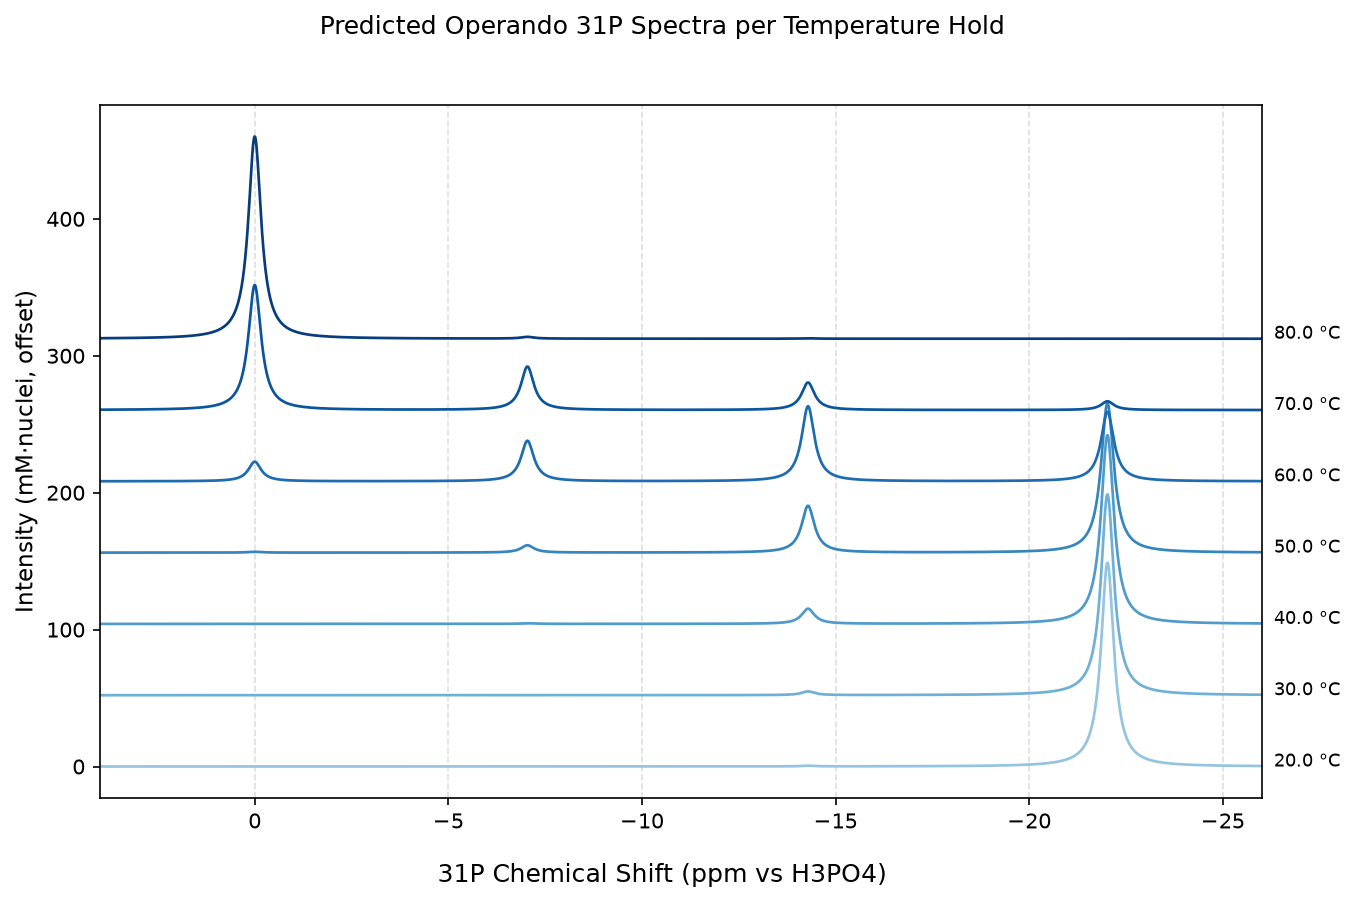

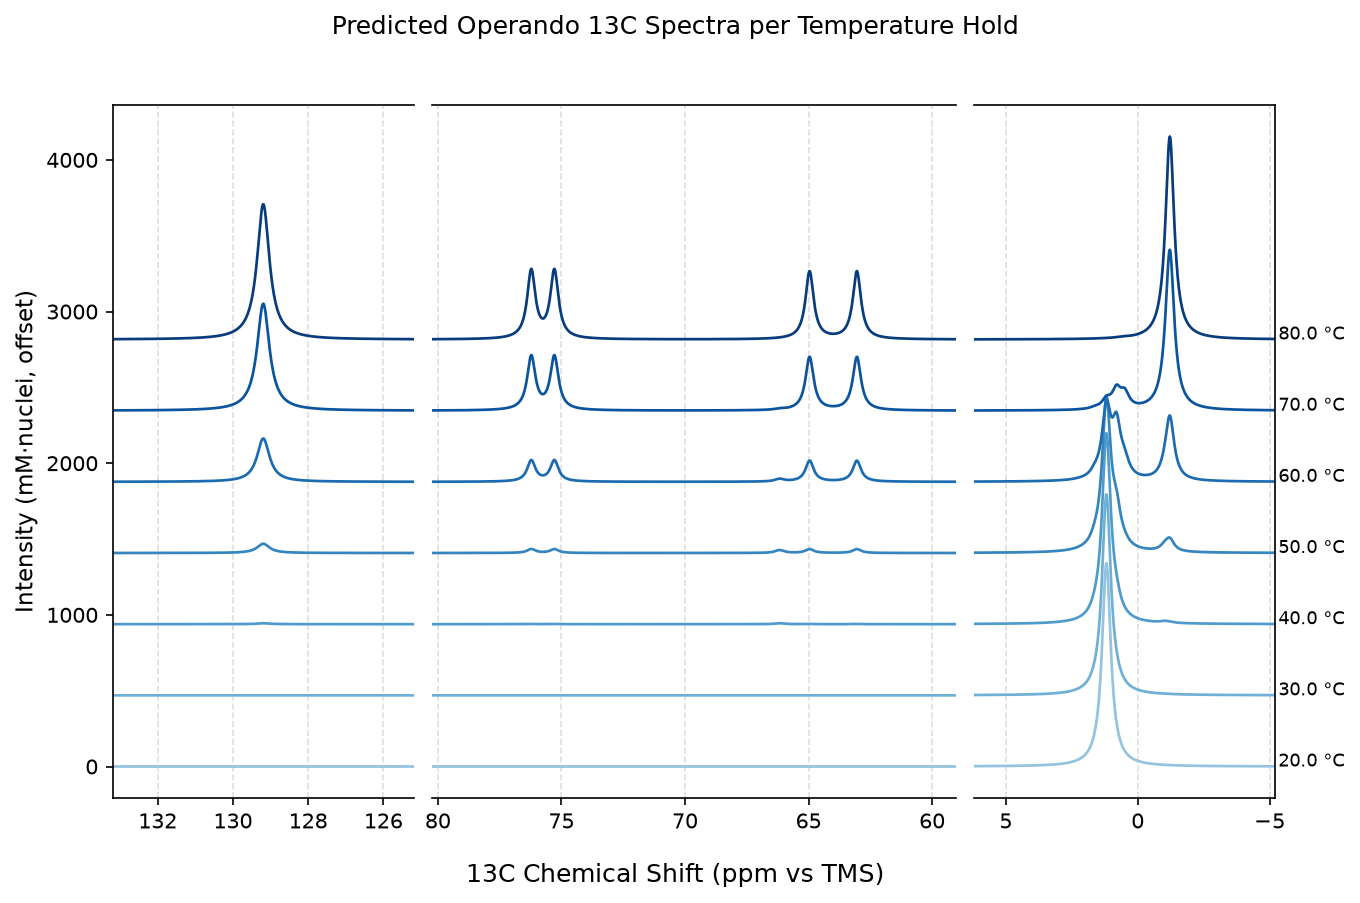

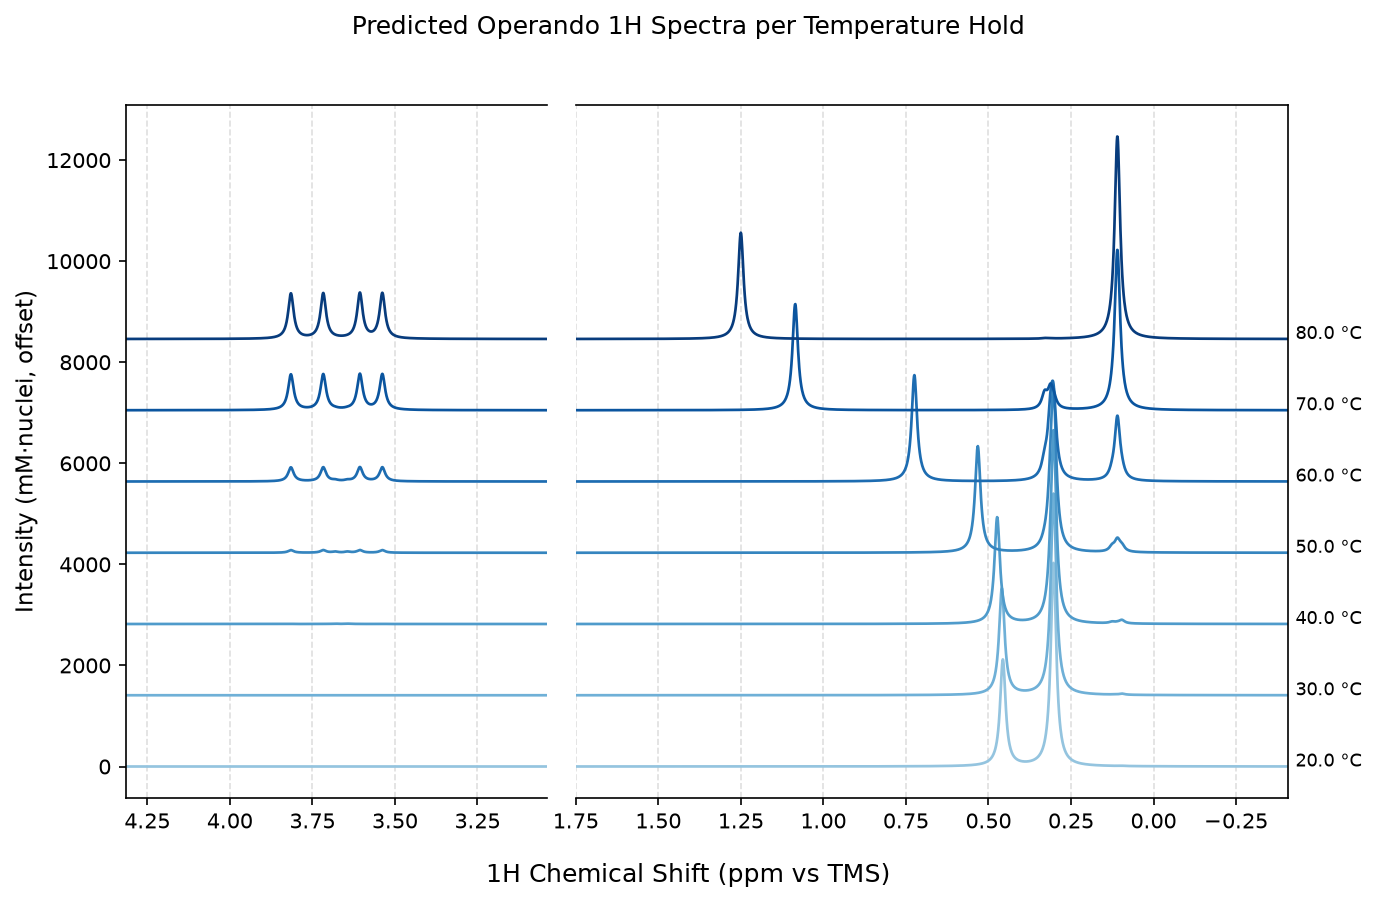

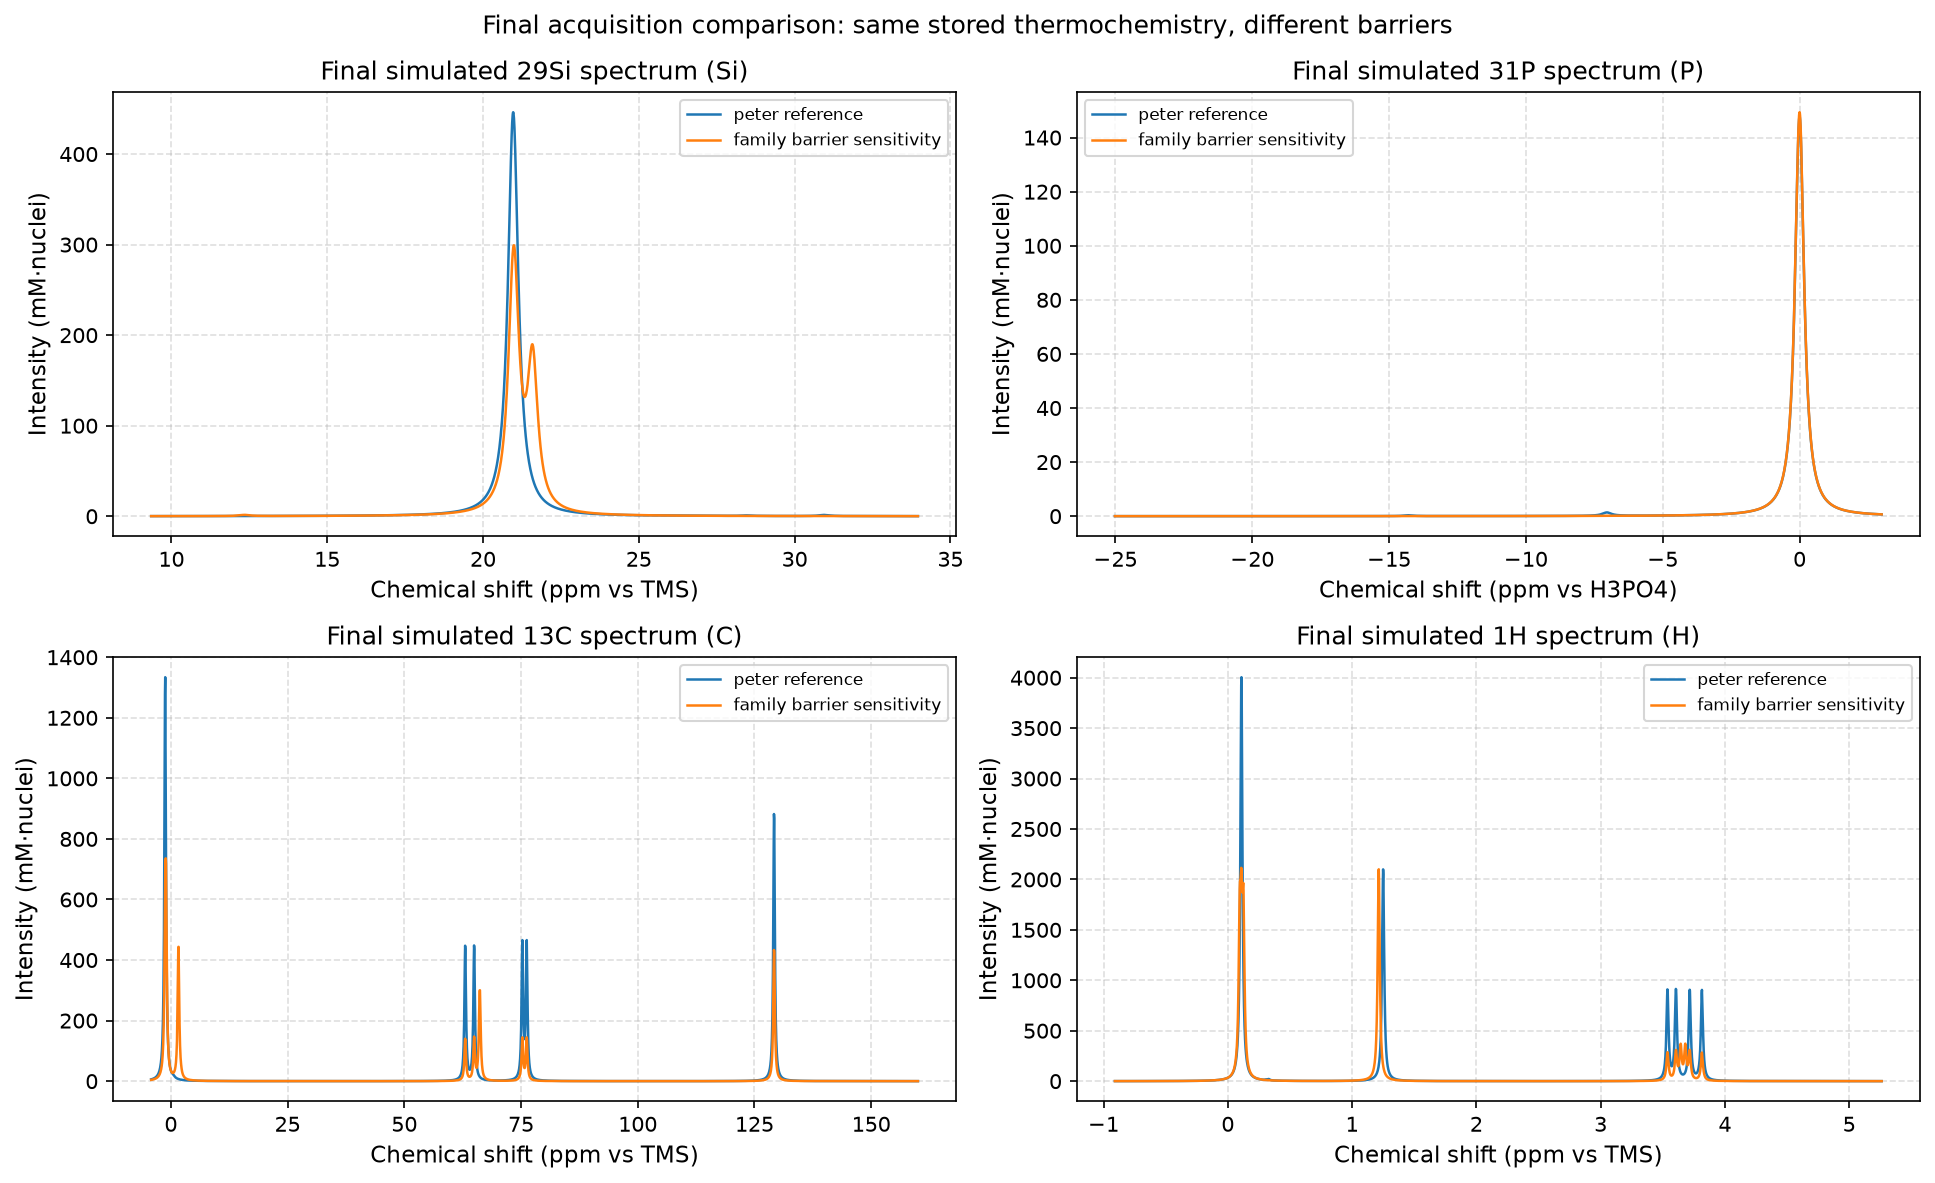

In [7]:
catalog = build_referenced_nmr_sites()

def plot_stacked_spectra(element, lw=0.4, pad=4.0, max_gap=40.0):
    ref, iso = DEFAULT_NUCLEI[element]
    c_snaps = np.array([s['C'] for s in sim['snapshots']]).T
    peaks = site_peaks(element, c_snaps, sim['idx'], nmr_sites_catalog=catalog)
    
    shifts = [d for _, s_vec, _ in peaks for d in [s_vec.min(), s_vec.max()]]
    regions = auto_regions(shifts, pad=pad, max_gap=max_gap)
    widths = [hi - lo for hi, lo in regions]
    ratios = [max(w, 0.3 * sum(widths)) for w in widths]
    grids = [np.linspace(hi, lo, 2000) for hi, lo in regions]
    
    specs = [simulate_multinuclear_spectra(element, c_snaps, sim['idx'], x, lw=lw, nmr_sites_catalog=catalog) for x in grids]
    peak_max = max(s.max() for s in specs)
    step_offset = peak_max * 0.35
    
    fig, axes = plt.subplots(1, len(regions), figsize=(10, 6), sharey=True, gridspec_kw={'width_ratios': ratios, 'wspace': 0.05})
    axes = np.atleast_1d(axes)
    shades = plt.cm.Blues(np.linspace(0.4, 0.95, len(sim['snapshots'])))
    
    for k, (ax, (hi, lo), x, S) in enumerate(zip(axes, regions, grids, specs)):
        for i, col in enumerate(shades):
            ax.plot(x, S[i] + i * step_offset, color=col, lw=1.3)
        ax.set_xlim(hi, lo)
        ax.grid(True, axis='x')
        if k > 0:
            ax.spines['left'].set_visible(False)
            ax.tick_params(left=False)
        if k < len(axes) - 1:
            ax.spines['right'].set_visible(False)
            
    for i, snap in enumerate(sim['snapshots']):
        axes[-1].annotate(f"{snap['T_C']} °C", xy=(1.01, i * step_offset), xycoords=('axes fraction', 'data'), fontsize=8.5)
        
    fig.supxlabel(f"{iso} Chemical Shift (ppm vs {ref})")
    axes[0].set_ylabel("Intensity (mM·nuclei, offset)")
    fig.suptitle(f"Predicted Operando {iso} Spectra per Temperature Hold")
    plt.tight_layout()
    plt.show()

for el in ['Si', 'P', 'C', 'H']:
    lw_val = 0.02 if el == 'H' else 0.4
    plot_stacked_spectra(el, lw=lw_val, pad=0.5 if el == 'H' else 4.0, max_gap=2.0 if el == 'H' else 40.0)


if MODEL_VARIANT == 'compare_available':
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    for ax, element in zip(axes.flat, ['Si', 'P', 'C', 'H']):
        shifts = [shift for sites in catalog.get(element, {}).values()
                  for shift, _, _ in sites]
        if not shifts:
            ax.set_visible(False)
            continue
        pad = 1.0 if element == 'H' else 3.0
        x_grid = np.linspace(max(shifts) + pad, min(shifts) - pad, 3000)
        linewidth = 0.02 if element == 'H' else 0.4
        for variant_name, case in simulations.items():
            last_acquisition = np.asarray(case['snapshots'][-1]['C'])[:, None]
            spectrum = simulate_multinuclear_spectra(
                element, last_acquisition, case['idx'], x_grid,
                lw=linewidth, nmr_sites_catalog=catalog
            )[0]
            ax.plot(x_grid, spectrum, label=variant_name.replace('_', ' '), lw=1.2)
        ax.set_title(f"Final simulated {DEFAULT_NUCLEI[element][1]} spectrum ({element})")
        ax.set_xlabel(f"Chemical shift (ppm vs {DEFAULT_NUCLEI[element][0]})")
        ax.set_ylabel('Intensity (mM·nuclei)')
        ax.grid(True)
        ax.legend(frameon=True, fontsize=8)
    fig.suptitle('Final acquisition comparison: same stored thermochemistry, different barriers')
    plt.tight_layout()
    plt.show()


## 5. Dinámica de Protones Lábiles y Balance Analítico de Agua

En disolución húmeda de EC, todos los protones lábiles (-OH) intercambian a escala más rápida que la resolución del espectrómetro, coalesciendo en un único pico promediado por población. Como la concentración total de protones OH es un invariante estequiométrico ($2 [\text{H}_2\text{O}]_0$), el agua se deduce de forma exacta por balance de masa a partir de las resonancias medibles de las demás especies:

$$[\text{H}_2\text{O}](t) = [\text{H}_2\text{O}]_0 - \frac{1}{2} \sum_{i \ne \text{H}_2\text{O}} n_{i,\text{OH}} \, C_i(t)$$


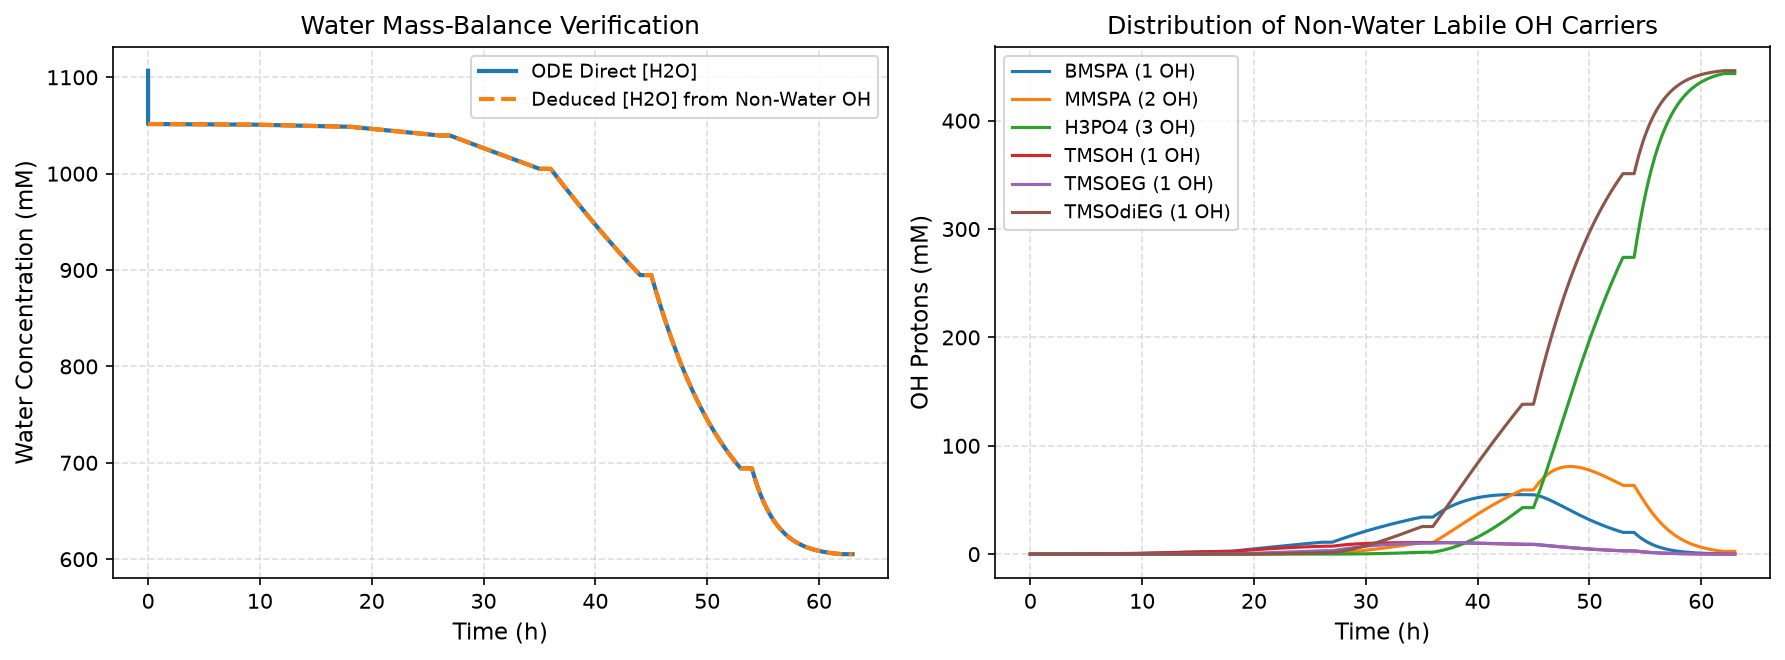

In [8]:
wb = compute_water_mass_balance(
    sim['C_M'],
    sim['idx'],
    initial_h2o_molarity=recipe['after']['H2O'],
    nmr_sites_catalog=catalog
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

post_inj = np.where(sim['t_h'] >= 0)[0]
ax1.plot(sim['t_h'][post_inj], wb['h2o_direct_M'][post_inj]*1000, label='ODE Direct [H2O]', lw=2.0)
ax1.plot(sim['t_h'][post_inj], wb['h2o_deduced_M'][post_inj]*1000, '--', label='Deduced [H2O] from Non-Water OH', lw=2.0)
ax1.set_xlabel('Time (h)')
ax1.set_ylabel('Water Concentration (mM)')
ax1.set_title('Water Mass-Balance Verification')
ax1.legend(frameon=True)
ax1.grid(True)

for col in wb['carriers_df'].columns:
    if 'H2O' not in col:
        ax2.plot(sim['t_h'][post_inj], wb['carriers_df'][col].values[post_inj], label=col, lw=1.5)
ax2.set_xlabel('Time (h)')
ax2.set_ylabel('OH Protons (mM)')
ax2.set_title('Distribution of Non-Water Labile OH Carriers')
ax2.legend(frameon=True)
ax2.grid(True)

plt.tight_layout()
plt.show()


## 6. Quimiometría: Huellas de Reacción, Identifiabilidad SVD e Inversión $\Delta\boldsymbol{\xi}$

### 6.1. Espacio de Características Multinuclear y Espectros Puros
Concatena las mallas de frecuencia de los cuatro núcleos ($^{29}\text{Si}, ^{31}\text{P}, ^{13}\text{C}, ^{1}\text{H}$) y construye la matriz de espectros puros $\mathbf{P}_{\text{pure}}$ de los componentes visibles.


In [9]:
catalog = build_referenced_nmr_sites()
species = ['TMSPA', 'BMSPA', 'MMSPA', 'H3PO4', 'H2O', 'TMSOH', 'HMDSO', 'TMSOEG', 'TMSOdiEG', 'CO2']
visible = [sp for sp in species if sp != 'EC' and any(not lab for el in ['Si', 'P', 'C', 'H'] for _, _, lab in catalog.get(el, {}).get(sp, []))]

grids, x_concat, blocks, n_feat = build_multinuclear_feature_space(visible, catalog)
p_pure = build_pure_component_matrix(visible, x_concat, blocks, n_feat, catalog)

print(f"Visible species ({len(visible)}): {', '.join(visible)}")
print(f"Total concatenated feature dimensions: {n_feat} features across 4 nuclei.")


Visible species (9): TMSPA, BMSPA, MMSPA, H3PO4, TMSOH, HMDSO, TMSOEG, TMSOdiEG, CO2
Total concatenated feature dimensions: 4200 features across 4 nuclei.


### 6.2. Huellas Estequiométricas de Reacción $\mathbf{F}$ y Rango SVD
Calcula las huellas estequiométricas $\mathbf{F} = \mathbf{S}_{\text{vis}} \cdot \mathbf{P}_{\text{pure}}$ normalizadas por varianza de bloque. El análisis de descomposición en valores singulares (SVD) demuestra que $\operatorname{rank}(\mathbf{F}) = 6 < 9$: la silanolisis ($R_5, R_6, R_7$) es espectroscópicamente idéntica a hidrólisis + condensación ($R_{1-3} + R_4$). Se proyecta sobre la base agrupada identifiables $\mathbf{F}_{\mathcal{B}}$.


In [10]:
rxns = [
    ('R1', ['TMSPA', 'H2O'],   ['BMSPA',    'TMSOH']),
    ('R2', ['BMSPA', 'H2O'],   ['MMSPA',    'TMSOH']),
    ('R3', ['MMSPA', 'H2O'],   ['H3PO4',    'TMSOH']),
    ('R4', ['TMSOH', 'TMSOH'], ['HMDSO',    'H2O']),
    ('R5', ['TMSPA', 'TMSOH'], ['BMSPA',    'HMDSO']),
    ('R6', ['BMSPA', 'TMSOH'], ['MMSPA',    'HMDSO']),
    ('R7', ['MMSPA', 'TMSOH'], ['H3PO4',    'HMDSO']),
    ('R8', ['EC',    'TMSOH'], ['TMSOEG',   'CO2']),
    ('R9', ['EC',    'TMSOEG'], ['TMSOdiEG', 'CO2']),
]

f_norm, f_raw, weights, s_vis = build_reaction_fingerprints(rxns, visible, p_pure, blocks)
analysis = analyze_reaction_identifiability(f_norm, f_raw, [r[0] for r in rxns], blocks)

print(f"Reaction Network Numerical Rank: {analysis['effective_rank']} of {len(rxns)} elementary steps.")
print(f"Linearly Independent (Lumped) Basis Reactions:")
for label in analysis['lumped_labels']:
    print(f"  • {label}")


Reaction Network Numerical Rank: 6 of 9 elementary steps.
Linearly Independent (Lumped) Basis Reactions:
  • R1 ⊕ R5
  • R2 ⊕ R6
  • R3 ⊕ R7
  • R4 ⊕ R5,R6,R7
  • R8
  • R9


### 6.3. Señal Neta de Analito (NAS) y Matriz de Selectividad Nuclear
Cuantifica la fracción ortogonal exclusiva de señal observable para cada núcleo químico:
$$\text{sel}_{j, X} = \frac{\|\mathbf{NAS}_{j, X}\|_2}{\|\mathbf{f}_{j, X}\|_2} \in [0, 1]$$


In [11]:
sel_df = analysis['selectivity_df']
print("Nuclear Selectivity Table:")
sel_df.round(2)


Nuclear Selectivity Table:


,29Si,31P,13C,1H,all nuclei
R1 ⊕ R5,0.92,0.82,0.97,0.85,0.98
R2 ⊕ R6,0.88,0.71,0.91,0.83,0.96
R3 ⊕ R7,0.82,0.82,0.81,0.86,0.94
"R4 ⊕ R5,R6,R7",0.79,NaN,0.89,0.92,0.94
R8,0.10,NaN,0.84,0.65,0.77
R9,0.10,NaN,0.98,0.68,0.82


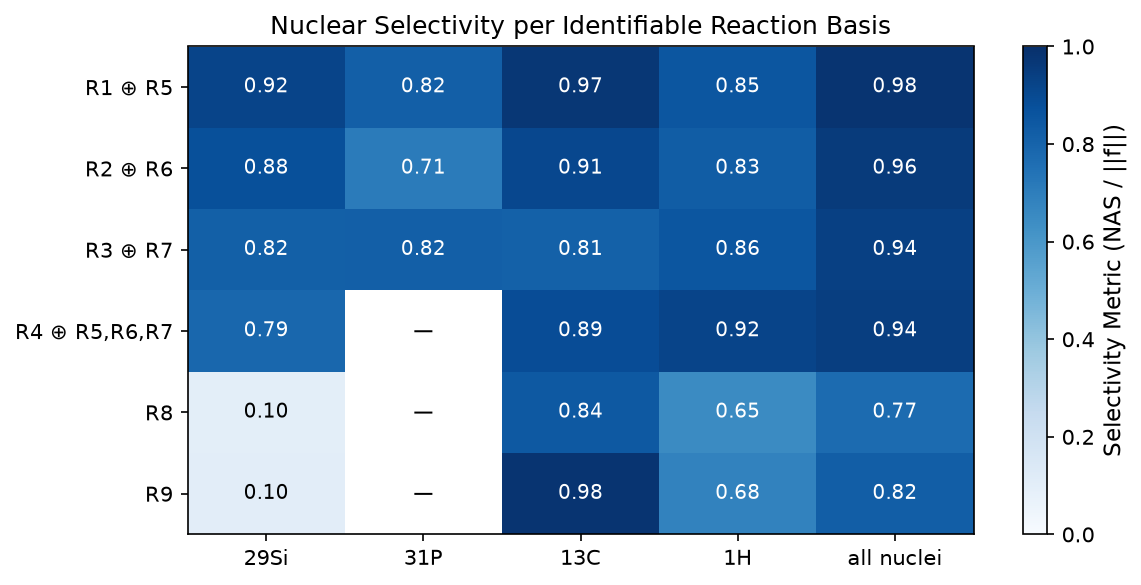

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
masked = np.ma.masked_invalid(sel_df.values)
cax = ax.imshow(masked, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(sel_df.columns)))
ax.set_xticklabels(sel_df.columns, fontsize=10)
ax.set_yticks(range(len(sel_df.index)))
ax.set_yticklabels(sel_df.index, fontsize=10)

for (j, c), v in np.ndenumerate(sel_df.values):
    ax.text(c, j, '—' if np.isnan(v) else f"{v:.2f}", ha='center', va='center',
            color='white' if not np.isnan(v) and v > 0.6 else 'black', fontsize=9.5)

plt.colorbar(cax, label='Selectivity Metric (NAS / ||f||)')
plt.title('Nuclear Selectivity per Identifiable Reaction Basis')
plt.tight_layout()
plt.show()


### 6.4. Recuperación de Avances de Reacción ($\Delta\boldsymbol{\xi}$) a partir de Espectros con Ruido
Añade ruido sintético a los espectros calculados e invierte sus diferencias mediante pseudoinversa regularizada $\mathbf{F}_{\mathcal{B}}^\dagger$ para recuperar los avances agrupados $\Delta\boldsymbol{\xi}$, validando la recuperabilidad analítica del pipeline.


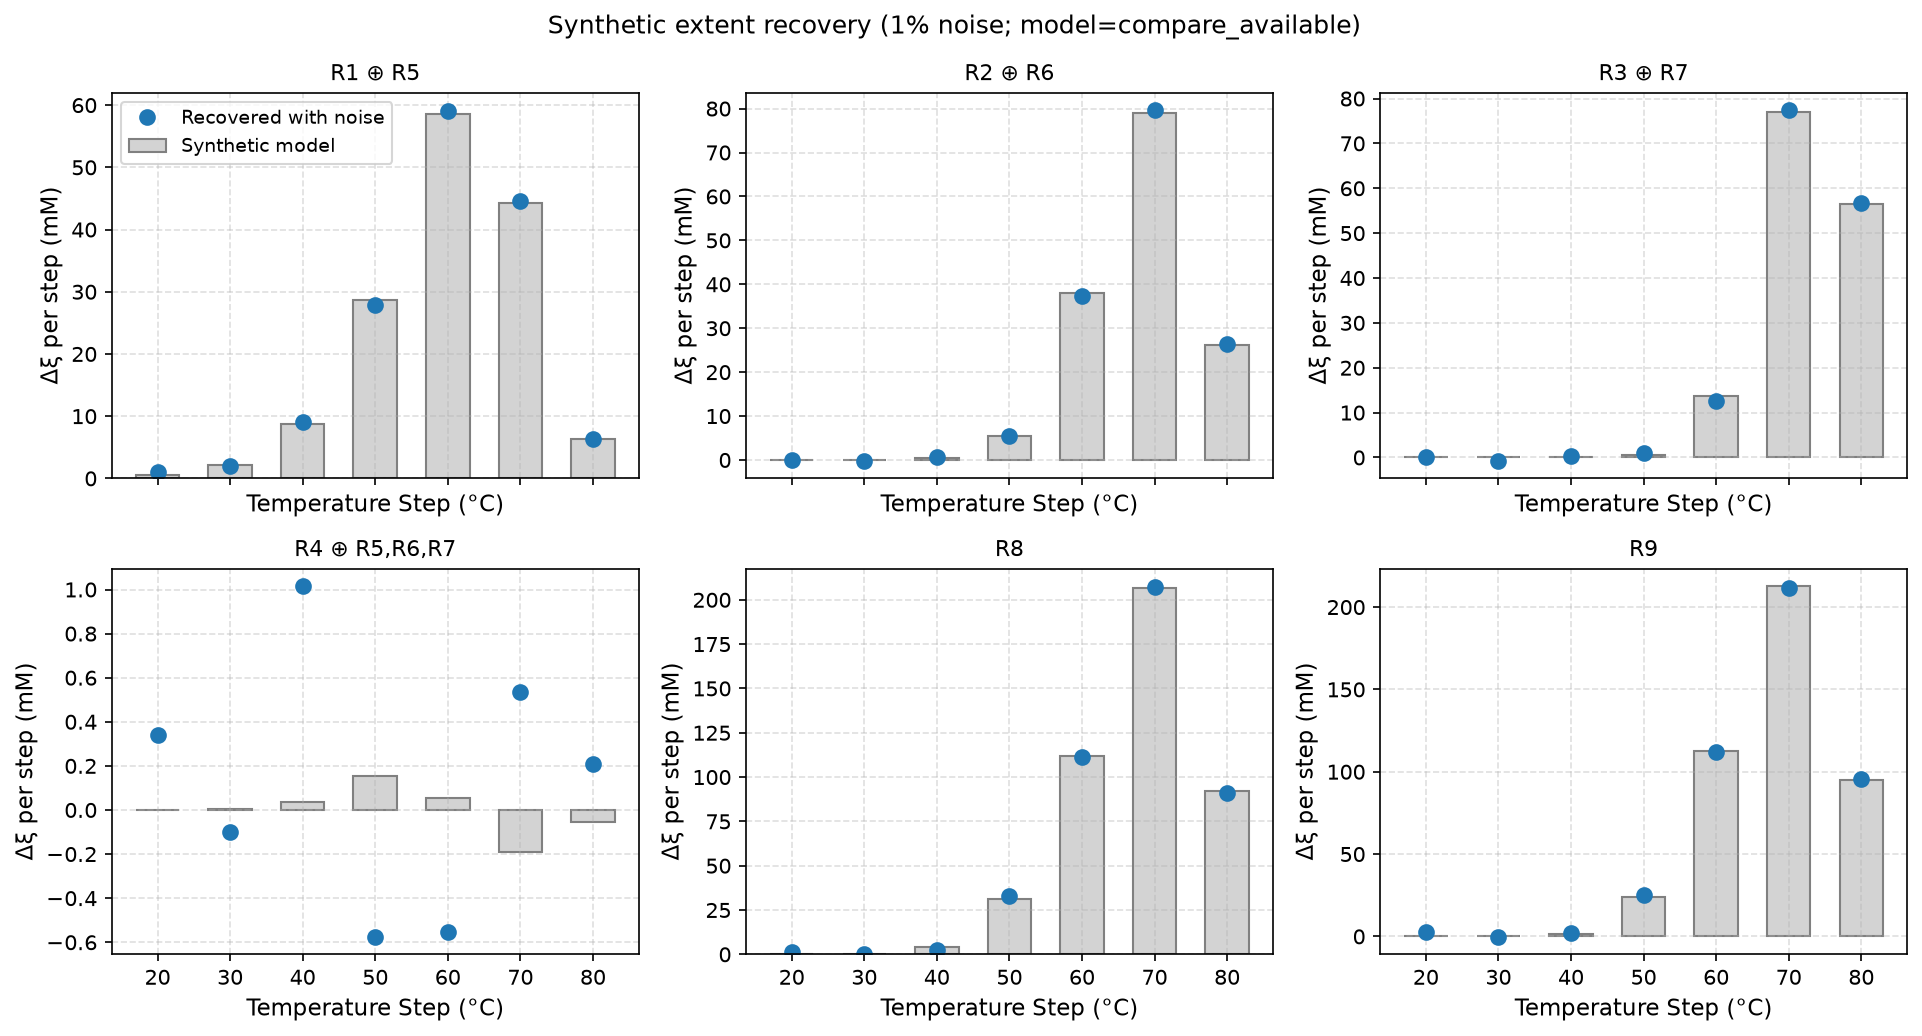

In [13]:
# Synthetic recovery only: the spectra are generated from this model's own concentrations and shifts.
i0 = INJECTION_STAGE_IDX * POINTS_PER_STAGE
i_snaps = [(i + 1) * POINTS_PER_STAGE - 1
           for i, stage in enumerate(stages) if stage[3] is not None]
step_idx = [i0] + i_snaps
step_temps = [snap['T_C'] for snap in sim['snapshots']]

vis_idx = [sim['idx'][sp] for sp in visible]
c_vis_snapshots = sim['C_M'][vis_idx][:, step_idx]
d_true = (c_vis_snapshots.T * 1000.0) @ p_pure

NOISE_REL = 0.01
rng = np.random.default_rng(42)
d_meas = d_true.copy()
for element, sl in blocks.items():
    sigma = NOISE_REL * np.abs(d_true[:, sl]).max()
    d_meas[:, sl] += rng.normal(0, sigma, d_true[:, sl].shape)

dD_measured = np.diff(d_meas, axis=0)
dD_true = np.diff(d_true, axis=0)
xi_hat = recover_reaction_extents(dD_measured, analysis['F_basis_norm'], weights)
xi_true = recover_reaction_extents(dD_true, analysis['F_basis_norm'], weights)

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
for j, ax in enumerate(axes.flat):
    if j < len(analysis['lumped_labels']):
        ax.bar(step_temps, xi_true[:, j], width=6, color='lightgray', edgecolor='gray', label='Synthetic model')
        ax.plot(step_temps, xi_hat[:, j], 'o', color='C0', ms=7, label='Recovered with noise')
        ax.set_title(analysis['lumped_labels'][j], fontsize=10.5)
        ax.set_ylabel('Δξ per step (mM)')
        ax.grid(True)
        if j == 0:
            ax.legend(frameon=True)
    else:
        ax.set_visible(False)
    ax.set_xlabel('Temperature Step (°C)')

plt.suptitle(f"Synthetic extent recovery ({NOISE_REL:.0%} noise; model={MODEL_VARIANT})")
plt.tight_layout()
plt.show()
